In [73]:
# https://judge.nitro-ai.org/competitions/rm-olimpiada-ai/simulation-1/2/view

import os 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from tqdm.auto import tqdm 

In [74]:
train = pd.read_csv("train_data.csv")
test = pd.read_csv("test_data.csv")
subm = pd.read_csv("sample_output.csv")

train.shape, test.shape, subm.shape 

((19073, 452), (19073, 450), (19081, 3))

In [75]:
train

,card_id,target,outliers,feature_1,feature_2,feature_3,year,month_fa,quarter,dayofyear,...,hist_CLV,CLV_ratio,hist_trans_velocity,new_trans_velocity,auth_ratio,unauth_ratio,auth_purchase_ratio,purchase_amount_diff,month_lag_diff,outlier_prob
0,C_ID_ca4934b035,-0.675572,0,0.010479,0.014166,0.011428,2016,7,3,183,...,-9246.311133,0.000621,0.396181,1.081081e-01,0.981928,0.018072,0.984456,-0.029967,8.183735,0.001065
1,C_ID_b782ea5601,-5.291554,0,0.013145,0.008752,0.011428,2017,1,1,1,...,2.353457,-0.334644,0.021021,1.111111e-01,1.000000,NaN,1.000000,-0.496706,7.857143,0.007524
2,C_ID_295513ec3b,-0.017979,0,0.008058,0.011385,0.010283,2017,12,4,335,...,-2916.904940,0.109024,1.439024,6.603774e-01,0.974576,0.025424,1.047056,-0.105554,2.234867,0.000253
3,C_ID_f3c693b4c9,0.840737,0,0.010610,0.008752,0.010283,2016,5,2,122,...,-6249.614162,0.000027,0.545961,1.000000e+09,0.954082,0.045918,0.953625,-0.006191,6.372449,0.047097
4,C_ID_b95f40083d,0.305347,0,0.013145,0.011385,0.011428,2017,11,4,305,...,-189.245218,0.011395,0.430556,1.363636e-01,1.000000,NaN,1.000000,-0.121705,3.311828,0.000517
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19068,C_ID_58ec973793,-1.043523,0,0.010479,0.008752,0.011428,2016,10,4,275,...,-337.557087,0.016851,0.110759,6.666667e-01,0.828571,0.171429,0.793659,-0.152045,5.257143,0.002467
19069,C_ID_66bdd97ea0,-0.004528,0,0.013145,0.008752,0.011428,2017,2,1,32,...,-6669.824667,0.006128,0.380822,2.790698e-01,0.863309,0.136691,0.862308,0.125203,5.212230,0.000759
19070,C_ID_8401bed595,4.041923,0,0.010479,0.011385,0.011428,2017,12,4,335,...,-376.565136,0.000962,0.550725,1.000000e+09,0.947368,0.052632,0.989990,-0.202810,2.763158,0.000511
19071,C_ID_64f0e494e8,2.351951,0,0.010712,0.008752,0.010283,2016,10,4,275,...,-12.599417,NaN,0.031250,NaN,0.888889,0.111111,0.880118,NaN,NaN,0.063831


In [76]:
train['outliers'].mean()

np.float64(0.010957898600115347)

In [77]:
test['outlier_prob']

0        0.001921
1        0.005908
2        0.002852
3        0.000900
4        0.010559
           ...   
19068    0.023081
19069    0.001770
19070    0.000457
19071    0.031831
19072    0.001723
Name: outlier_prob, Length: 19073, dtype: float64

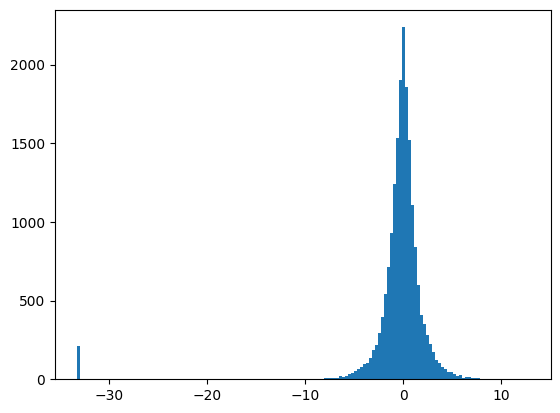

In [78]:
plt.hist(train['target'], bins=150)
plt.show()

In [79]:
subm.iloc[:8, 2] = [
    ((train['target'] < -10).astype(int)).sum().item(),
    ((train['target'] < 0).astype(int) * (train['target'] >= -10).astype(int)).sum().item(),
    ((train['target'] < 5).astype(int) * (train['target'] >= 0).astype(int)).sum().item(),
    ((train['target'] >= 5).astype(int)).sum().item(),

    ((train['hist_transactions_count'] <= 10).astype(int)).sum().item(),
    ((train['hist_transactions_count'] >= 11).astype(int) * (train['hist_transactions_count'] <= 50).astype(int)).sum().item(),
    ((train['hist_transactions_count'] >= 51).astype(int) * (train['hist_transactions_count'] <= 100).astype(int)).sum().item(),
    ((train['hist_transactions_count'] > 100).astype(int)).sum().item(),
]

In [80]:
from sklearn.model_selection import train_test_split 

X, y = train.drop(columns=['card_id', 'target', 'outliers']), train['target']
X_test = test.drop(columns=['card_id'])

X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state=42, test_size=0.1)
X_train.shape, X_valid.shape 

((17165, 449), (1908, 449))

In [81]:
from catboost import Pool 

train_pool = Pool(X_train, y_train)
valid_pool = Pool(X_valid, y_valid)

In [82]:
from catboost import CatBoostRegressor 

params = {
    'iterations': 100,
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'metric_period': 10,
    'max_depth': 2,
    'random_state': 42,
    'learning_rate': 0.1,
}

model = CatBoostRegressor(**params)

model.fit(train_pool, eval_set=valid_pool)

0:	learn: 3.8201568	test: 3.8503182	best: 3.8503182 (0)	total: 6.33ms	remaining: 627ms
10:	learn: 3.6848006	test: 3.8005785	best: 3.8005785 (10)	total: 43.4ms	remaining: 351ms
20:	learn: 3.6400809	test: 3.7974849	best: 3.7974849 (20)	total: 83.4ms	remaining: 314ms
30:	learn: 3.6156099	test: 3.8059996	best: 3.7974849 (20)	total: 124ms	remaining: 276ms
40:	learn: 3.6051694	test: 3.8026619	best: 3.7974849 (20)	total: 166ms	remaining: 239ms
50:	learn: 3.5941409	test: 3.8006852	best: 3.7974849 (20)	total: 204ms	remaining: 196ms
60:	learn: 3.5827971	test: 3.8025148	best: 3.7974849 (20)	total: 243ms	remaining: 155ms
70:	learn: 3.5759028	test: 3.8018152	best: 3.7974849 (20)	total: 277ms	remaining: 113ms
80:	learn: 3.5653919	test: 3.8033947	best: 3.7974849 (20)	total: 313ms	remaining: 73.5ms
90:	learn: 3.5570807	test: 3.8023813	best: 3.7974849 (20)	total: 348ms	remaining: 34.4ms
99:	learn: 3.5503652	test: 3.8050223	best: 3.7974849 (20)	total: 381ms	remaining: 0us

bestTest = 3.797484858
bestIte

CatBoostRegressor(eval_metric='RMSE', iterations=100, learning_rate=0.1, loss_function='RMSE', max_depth=2, metric_period=10, random_state=42)

In [83]:
subm.iloc[8:, 2] = model.predict(X_test)

/var/folders/fj/6l4ss8j95896j5mg2fvdst700000gp/T/ipykernel_9811/831869919.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.00226891 -0.34488043  0.20124979 ... -0.33811923 -1.42166805
 -0.14740966]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  subm.iloc[8:, 2] = model.predict(X_test)


In [84]:
subm.to_csv("submission.csv", index=False)
subm

,subtaskID,datapointID,answer
0,1,very_low_loyalty,215.000000
1,1,low_loyalty,9520.000000
2,1,medium_loyalty,9187.000000
3,1,high_loyalty,151.000000
4,2,very_short_history,1032.000000
...,...,...,...
19076,3,C_ID_b366323ca5,-0.690820
19077,3,C_ID_884180e176,-0.227506
19078,3,C_ID_1510bdf423,-0.338119
19079,3,C_ID_6f08e7cdaa,-1.421668
